In [1]:
# --- Imports -----------------------------------------------------------------
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from libpysal.weights import DistanceBand, lag_spatial
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
import seaborn as sns
# --- Load shapefile ----------------------------------------------------------
gdf = gpd.read_file('../Data/Shapefiles/20240627_APES FINAL_metric.shp')

# --- Filter & basic cleaning -------------------------------------------------
# remove ZIKV, drop empty geometries
gdf = gdf.loc[gdf['RcrdTyp'] != 'ZIKV'].copy()
gdf = gdf.loc[~gdf.geometry.is_empty & gdf.geometry.notna()].copy()

# columns
id_cols = ["NUTS_NA", "NUTS_CO"]
predictor_cols = [
    "Forest", "Shrub", "Urban", "Crop", "Water", "Other",
    "Mn_P_Wn",   # Mean_P_Winter
    "Mx_WD_W",   # Max_WD_Winter
    "Mx_DD_W",   # Max_DD_Winter
    "Mn_T_Sp",   # Mean_T_Spring
    "Mx_DD_Sp",  # Max_DD_Spring
    "Mn_T_Sm",   # Mean_T_Summer  (included to match your R comment)
    "Mx_WD_A",   # Max_WD_Autumn
    "Mx_DD_A",   # Max_DD_Autumn
    "gdp", "pop_dns"
]
response_col = "incidnc"


# keep only available columns (plus geometry and IDs)
keep = [c for c in (id_cols + predictor_cols + [response_col, "geometry"]) if c in gdf.columns]
gdf = gdf[keep].copy()

# --- Aggregate to NUTS level -------------------------------------------------
# incidence = sum; all predictors = mean (like your R summarise)
agg_dict = {response_col: "sum"}
agg_dict.update({c: "mean" for c in predictor_cols if c in gdf.columns})

fin_eu3 = (
    gdf
    .groupby(id_cols, as_index=False)
    .agg(agg_dict)
)

# restore a representative geometry per NUTS (assumes unique geometry per NUTS)
geom_first = (
    gdf[id_cols + ["geometry"]]
    .drop_duplicates(id_cols)
)
fin_eu3 = fin_eu3.merge(geom_first, on=id_cols, how="left")
fin_eu3 = gpd.GeoDataFrame(fin_eu3, geometry="geometry", crs=gdf.crs)

# drop rows with any NA in variables we need
needed = [response_col] + [c for c in predictor_cols if c in fin_eu3.columns]
fin_eu3 = fin_eu3.dropna(subset=needed).copy()



# --- Project to metric CRS and compute centroids -----------------------------
# Use a metric CRS for distances (UTM zone 33N as in your R code)
fin_eu3 = fin_eu3.to_crs(32633)
centroids = fin_eu3.geometry.centroid  # in meters now
coords = np.c_[centroids.x, centroids.y]



# Replace StandardScaler with manual z-score using ddof=1
num_cols = fin_eu3.select_dtypes(include="number").columns.tolist()

fin_eu3_std = fin_eu3.copy()
for c in num_cols:
    s = fin_eu3[c]
    fin_eu3_std[c] = (s - s.mean()) / s.std(ddof=1)   # R's scale()

In [2]:

y_raw = fin_eu3_std["incidnc"].to_numpy()
X_base = fin_eu3_std[predictor_cols].to_numpy()

kernels = ["gaussian", "bisquare", "exponential"]   # add/remove kernels as you like
distances = list(range(100_000, 200_001, 10_000))   # 100–200 km by 10 km
eps = 1e-9

rows = []
RES = []
for d in distances:
    # Build binary distance-band weights (no row standardization) → SUM of neighbors
    w = DistanceBand.from_array(coords, threshold=d + eps, binary=True, silence_warnings=True)
    W = w.full()[0]  # dense 0/1 matrix

    # Isolated units diagnostic
    isolated = int((W.sum(axis=1) == 0).sum())

    # Spatial lag of y: Wy = SUM of neighbors' y (binary weights)
    Wy = W.dot(y_raw)
    y = Wy.reshape(-1, 1)
    X = X_base  # predictors unchanged

    for ker in kernels:
        try:
            # adaptive bandwidth by AICc
            bw = Sel_BW(coords, y, X, kernel=ker, fixed=False).search()
            res = GWR(coords, y, X, bw, kernel=ker, fixed=False, constant=True).fit()
            RES.append(res)

            rows.append({
                "kernel": ker,
                "fixed": False,                 # adaptive GWR
                "max_distance_m": d,
                "isolated_units": isolated,
                "bandwidth": bw,                # adaptive: neighbor count
                "AICc": float(res.aicc),
                "mean_localR2": float(res.localR2.mean()),
                "min_localR2":  float(res.localR2.min()),
                "max_localR2":  float(res.localR2.max()),
            })
            print(f"d={d/1000:.0f} km | {ker:10s} | bw={bw:4} | "
                  f"AICc={res.aicc:.1f} | R2 μ/lo/hi = "
                  f"{res.localR2.mean():.3f}/{res.localR2.min():.3f}/{res.localR2.max():.3f} | iso={isolated}")

        except Exception as e:
            rows.append({
                "kernel": ker,
                "fixed": False,
                "max_distance_m": d,
                "isolated_units": isolated,
                "bandwidth": np.nan,
                "AICc": np.nan,
                "mean_localR2": np.nan,
                "min_localR2":  np.nan,
                "max_localR2":  np.nan,
                "error": str(e),
            })
            print(f"d={d/1000:.0f} km | {ker:10s} | ERROR: {e}")

d=100 km | gaussian   | bw=75.0 | AICc=5995.3 | R2 μ/lo/hi = 0.756/0.491/0.892 | iso=28
d=100 km | bisquare   | bw=97.0 | AICc=5956.0 | R2 μ/lo/hi = 0.779/-1.661/0.968 | iso=28
d=100 km | exponential | bw=75.0 | AICc=5933.4 | R2 μ/lo/hi = 0.777/0.576/0.877 | iso=28
d=110 km | gaussian   | bw=75.0 | AICc=6136.8 | R2 μ/lo/hi = 0.770/0.506/0.905 | iso=12
d=110 km | bisquare   | bw=107.0 | AICc=6079.4 | R2 μ/lo/hi = 0.787/-0.400/0.968 | iso=12
d=110 km | exponential | bw=75.0 | AICc=6094.9 | R2 μ/lo/hi = 0.792/0.591/0.891 | iso=12
d=120 km | gaussian   | bw=75.0 | AICc=6426.7 | R2 μ/lo/hi = 0.779/0.513/0.914 | iso=7
d=120 km | bisquare   | bw=107.0 | AICc=6377.2 | R2 μ/lo/hi = 0.789/-0.538/0.976 | iso=7
d=120 km | exponential | bw=75.0 | AICc=6373.6 | R2 μ/lo/hi = 0.803/0.606/0.897 | iso=7
d=130 km | gaussian   | bw=75.0 | AICc=6634.6 | R2 μ/lo/hi = 0.788/0.526/0.922 | iso=6
d=130 km | bisquare   | bw=92.0 | AICc=6556.2 | R2 μ/lo/hi = 0.797/-1.650/0.980 | iso=6
d=130 km | exponential | bw=

In [3]:
ker='exponential'
d = 100000
w = DistanceBand.from_array(coords, threshold=d + eps, binary=True, silence_warnings=True)
W = w.full()[0]  # dense 0/1 matrix
# Isolated units diagnostic
isolated = int((W.sum(axis=1) == 0).sum())
# Spatial lag of y: Wy = SUM of neighbors' y (binary weights)
Wy = W.dot(y_raw)
y = Wy.reshape(-1, 1)
X = X_base  # predictors unchanged
bw = Sel_BW(coords, y, X, kernel=ker, fixed=False).search()
res = GWR(coords, y, X, bw, kernel=ker, fixed=False, constant=True).fit()

C:\Users\massaro\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Q:\UserTemp\massaro\AppData\Local\Temp\260\ipykernel_17848\276225955.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fin_eu3_std['gwr_localR2'], hist = False, kde = True,kde_kws = {'shade': True, 'linewidth': 3});
C:\Program Files\ArcGIS\Pro\bin\Python\envs\arcgispro-py3\Lib\site-packages\seaborn\distributions.py:2496: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


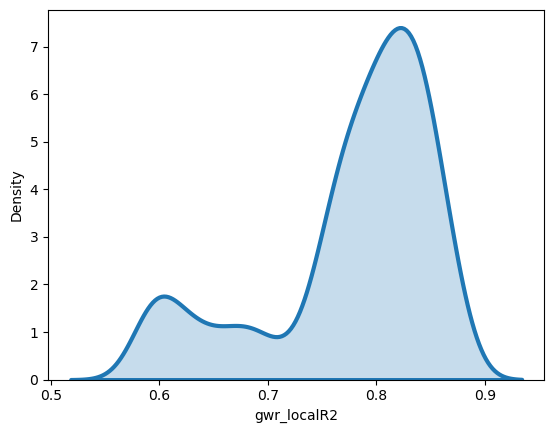

In [5]:
fin_eu3_std["gwr_localR2"] = res.localR2
fin_eu3_std["gwr_aicc"] = res.aicc
sns.distplot(fin_eu3_std['gwr_localR2'], hist = False, kde = True,kde_kws = {'shade': True, 'linewidth': 3});

<AxesSubplot: >

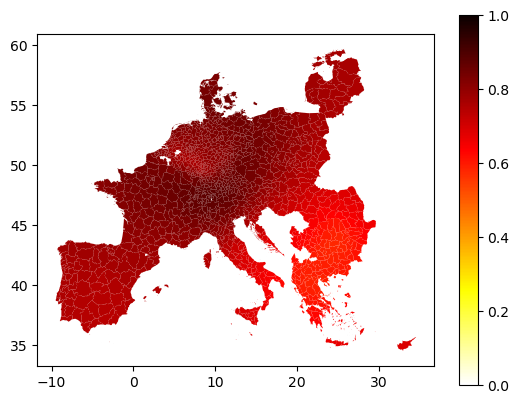

In [8]:
gdf_plot = fin_eu3_std.to_crs('EPSG:4326')
import pylab as plt
f,ax=plt.subplots()
gdf_plot.plot(ax=ax, column='gwr_localR2', cmap='hot_r', vmin=0, vmax=1, legend=True)

In [26]:
import statsmodels.api as sm
import pandas as pd
y = Wy.reshape(-1, 1)
X = X_base  # predictors unchanged
X_ols = sm.add_constant(X)

y_raw = fin_eu3_std["incidnc"]  # or your standardized version
X_ols = sm.add_constant(fin_eu3_std[predictor_cols])
ols_model = sm.OLS(y_raw, X_ols).fit()


ols_model = sm.OLS(y, X_ols).fit()
X_cols = fin_eu3_std[predictor_cols]
ols_summary = pd.DataFrame({
    "Covariate": ["Intercept"] + list(X_cols.columns),
    "Estimate": np.round(ols_model.params, 2),
    "SE": np.round(ols_model.bse, 2),
    "p-value": np.where(ols_model.pvalues < 0.001, "<.001", np.round(ols_model.pvalues, 3))
})
# --- OLS (linear model) ---
#X = fin_eu3_std[predictor_cols]
#y = fin_eu3_std["incidnc"]   # or your chosen dependent variable
ols_summary

,Covariate,Estimate,SE,p-value
const,Intercept,-1.89,0.13,<.001
Forest,Forest,-0.29,0.18,0.099
Shrub,Shrub,0.37,0.15,0.011
Urban,Urban,0.24,0.14,0.081
Crop,Crop,0.21,0.17,0.229
Water,Water,0.30,0.14,0.034
Other,Other,0.40,0.15,0.01
Mn_P_Wn,Mn_P_Wn,0.04,0.23,0.858
Mx_WD_W,Mx_WD_W,-0.39,0.27,0.154
Mx_DD_W,Mx_DD_W,-0.33,0.21,0.127


In [13]:
# --- OLS metrics ---
ols_diag = {
    "Residual std error (df)": f"{ols_model.mse_resid**0.5:.2f} ({int(ols_model.df_resid)})",
    "Multiple R-squared": f"{ols_model.rsquared:.3f}",
    "Adjusted R-squared": f"{ols_model.rsquared_adj:.3f}",
    "F-statistic (df)": f"{ols_model.fvalue:.1f} ({int(ols_model.df_model)}; {int(ols_model.df_resid)})",
    "p-value": "<.001" if ols_model.f_pvalue < 0.001 else round(ols_model.f_pvalue, 3)
}

In [14]:
ols_diag

{'Residual std error (df)': '4.25 (1117)',
 'Multiple R-squared': '0.479',
 'Adjusted R-squared': '0.472',
 'F-statistic (df)': '64.2 (16; 1117)',
 'p-value': '<.001'}

In [17]:
gwr_res = res
# --- GWR summaries (local coefficients) ---
gwr_coefs = pd.DataFrame(gwr_res.params, columns=["Intercept"] + list(X_cols.columns))

# Compute local coefficient quantiles
quantiles = gwr_coefs.quantile([0, 0.25, 0.5, 0.75, 1]).T
quantiles.columns = ["Min", "1Q", "Median", "3Q", "Max"]
quantiles = np.round(quantiles, 2).reset_index().rename(columns={"index": "Covariate"})

# --- Merge both ---
table1 = pd.merge(ols_summary, quantiles, on="Covariate", how="outer")
table1 = table1.fillna("")

In [18]:
table1

,Covariate,Estimate,SE,p-value,Min,1Q,Median,3Q,Max
0,Intercept,-1.89,0.13,<.001,-3.28,-2.59,-2.13,-1.70,-1.37
1,Forest,-0.29,0.18,0.099,-0.96,-0.22,0.06,0.33,0.78
2,Shrub,0.37,0.15,0.011,-2.47,-0.99,-0.12,0.81,1.88
3,Urban,0.24,0.14,0.081,-0.62,-0.05,0.15,0.27,0.62
4,Crop,0.21,0.17,0.229,-3.98,0.34,0.62,1.21,2.40
5,Water,0.30,0.14,0.034,-0.12,0.07,0.24,0.39,0.90
6,Other,0.40,0.15,0.01,0.16,0.37,0.51,0.68,1.19
7,Mn_P_Wn,0.04,0.23,0.858,-3.44,-0.15,0.26,0.90,1.62
8,Mx_WD_W,-0.39,0.27,0.154,-0.96,-0.40,-0.15,0.11,1.06
9,Mx_DD_W,-0.33,0.21,0.127,-0.74,0.63,0.84,1.10,2.05


In [19]:
# --- GWR metrics ---
gwr_diag = {
    "P5 R2": f"{np.percentile(gwr_res.localR2, 5):.2f}",
    "P95 R2": f"{np.percentile(gwr_res.localR2, 95):.2f}",
    "Mean R2": f"{np.mean(gwr_res.localR2):.2f}",
    "Median R2": f"{np.median(gwr_res.localR2):.2f}"
}

gwr_diag

{'P5 R2': '0.60', 'P95 R2': '0.86', 'Mean R2': '0.78', 'Median R2': '0.80'}

In [ ]:
# Save to CSV
out_path = 'sensitivity.csv'
sens_df = pd.DataFrame(rows).sort_values(["max_distance_m", "kernel"]).reset_index(drop=True)
out_path = f"sensitivity_gwr_Wy_binarysum_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
sens_df.to_csv(out_path, index=False)
print("Saved:", out_path)